# Gas Turbine Data


Problem statement: predicting turbine energy yield (TEY) using ambient variables as features.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In [2]:
# Import Dataset
data = pd.read_csv('E:\Assignment\Assignment 16 - Neural network\gas_turbines.csv')
data.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,6.8594,1007.9,96.799,3.5000,19.663,1059.2,550.00,114.70,10.605,3.1547,82.722
1,6.7850,1008.4,97.118,3.4998,19.728,1059.3,550.00,114.72,10.598,3.2363,82.776
2,6.8977,1008.8,95.939,3.4824,19.779,1059.4,549.87,114.71,10.601,3.2012,82.468
3,7.0569,1009.2,95.249,3.4805,19.792,1059.6,549.99,114.72,10.606,3.1923,82.670
4,7.3978,1009.7,95.150,3.4976,19.765,1059.7,549.98,114.72,10.612,3.2484,82.311


In [3]:
data.corr()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
AT,1.000000,-0.412953,-0.549432,-0.099333,-0.049103,0.093067,0.338569,-0.207495,-0.100705,-0.088588,-0.600006
AP,-0.412953,1.000000,0.042573,0.040318,0.078575,0.029650,-0.223479,0.146939,0.131198,0.041614,0.256744
AH,-0.549432,0.042573,1.000000,-0.119249,-0.202784,-0.247781,0.010859,-0.110272,-0.182010,0.165505,0.143061
AFDP,-0.099333,0.040318,-0.119249,1.000000,0.744251,0.627254,-0.571541,0.717995,0.727152,-0.334207,-0.037299
GTEP,-0.049103,0.078575,-0.202784,0.744251,1.000000,0.874526,-0.756884,0.977042,0.993784,-0.508259,-0.208496
TIT,0.093067,0.029650,-0.247781,0.627254,0.874526,1.000000,-0.357320,0.891587,0.887238,-0.688272,-0.231636
TAT,0.338569,-0.223479,0.010859,-0.571541,-0.756884,-0.357320,1.000000,-0.720356,-0.744740,0.063404,0.009888
TEY,-0.207495,0.146939,-0.110272,0.717995,0.977042,0.891587,-0.720356,1.000000,0.988473,-0.541751,-0.102631
CDP,-0.100705,0.131198,-0.182010,0.727152,0.993784,0.887238,-0.744740,0.988473,1.000000,-0.520783,-0.169103
CO,-0.088588,0.041614,0.165505,-0.334207,-0.508259,-0.688272,0.063404,-0.541751,-0.520783,1.000000,0.316743


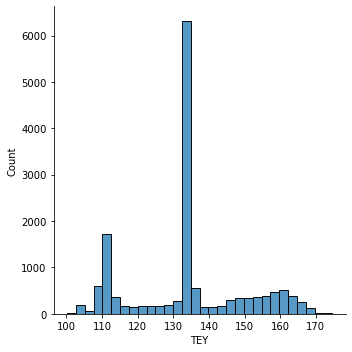

In [9]:
sns.displot(data['TEY'],bins=30)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15039 entries, 0 to 15038
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      15039 non-null  float64
 1   AP      15039 non-null  float64
 2   AH      15039 non-null  float64
 3   AFDP    15039 non-null  float64
 4   GTEP    15039 non-null  float64
 5   TIT     15039 non-null  float64
 6   TAT     15039 non-null  float64
 7   TEY     15039 non-null  float64
 8   CDP     15039 non-null  float64
 9   CO      15039 non-null  float64
 10  NOX     15039 non-null  float64
dtypes: float64(11)
memory usage: 1.3 MB


In [12]:
# Spliting dataset
X = data.drop('TEY',axis=1).values
y =data['TEY'].values

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=101)

In [16]:
# Preprocessing
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [17]:
model = Sequential()
model.add(Dense(200,input_dim=10, activation='tanh'))
model.add(Dense(100, activation='tanh'))
model.add(Dense(50, activation='tanh'))
model.add(Dense(1,activation='linear'))

In [18]:
# Compile model
model.compile(loss='mean_squared_error', optimizer='adam',metrics=['mse'])

In [20]:
history=model.fit(X_train,y_train,epochs=100,batch_size=10)

Epoch 1/100
1204/1204 [==============================] - 2s 929us/step - loss: 12980.5887 - mse: 12980.5887
Epoch 2/100
1204/1204 [==============================] - 1s 948us/step - loss: 3621.5656 - mse: 3621.5656
Epoch 3/100
1204/1204 [==============================] - 1s 889us/step - loss: 765.1495 - mse: 765.1495
Epoch 4/100
1204/1204 [==============================] - 1s 877us/step - loss: 282.0044 - mse: 282.0044
Epoch 5/100
1204/1204 [==============================] - 1s 916us/step - loss: 250.6889 - mse: 250.6889
Epoch 6/100
1204/1204 [==============================] - 1s 957us/step - loss: 246.5188 - mse: 246.5188
Epoch 7/100
1204/1204 [==============================] - 1s 971us/step - loss: 252.7805 - mse: 252.7805
Epoch 8/100
1204/1204 [==============================] - 1s 855us/step - loss: 247.3865 - mse: 247.3865
Epoch 9/100
1204/1204 [==============================] - 1s 1ms/step - loss: 255.1731 - mse: 255.1731
Epoch 10/100
1204/1204 [==============================] - 1s

In [21]:
scores = model.evaluate(X_test, y_test)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

94/94 [==============================] - 0s 721us/step - loss: 0.3291 - mse: 0.3291
mse: 32.91%


In [22]:
predictions = model.predict_classes(X_test)
predictions

C:\Users\hp\anaconda3\lib\site-packages\tensorflow\python\keras\engine\sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]])

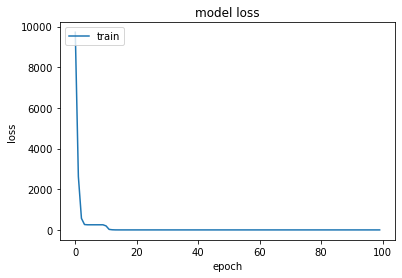

In [23]:
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Forest Fire

In [1]:
# Import Libraries
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing

In [3]:
# Import Dataset
dataset = pd.read_csv(r'E:\Assignment\Assignment 16 - Neural network\forestfires.csv')
dataset.head()

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
0,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,1,0,0,0,0,small
1,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,0,0,0,0,0,1,0,small
2,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0,0,0,1,0,small
3,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,1,0,0,0,0,small
4,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,0,0,0,0,1,0,0,0,0,small


In [4]:
data = dataset.drop(columns=['month','day','daymon','daytue','daywed','daythu','dayfri','daysat','daysun','monthjan','monthfeb','monthmar','monthapr','monthmay','monthjun','monthjul','monthaug','monthsep','monthoct','monthnov','monthdec'])

In [5]:
# Preprocessing
label_encoder = preprocessing.LabelEncoder()
data['size_category'] = label_encoder.fit_transform(data['size_category'])

In [6]:
array = data.values

In [7]:
array.shape

(517, 10)

In [8]:
# Spliting data
X = array[:, 0:9]
Y = array[:,9]

In [9]:
model = Sequential()
model.add(Dense(12,input_dim=9,activation= 'relu'))
model.add(Dense(12, activation = 'relu'))
model.add(Dense(8,activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [10]:
model.compile(loss='binary_crossentropy',optimizer = 'adam',metrics=['accuracy'])

In [11]:
model.fit(X,Y,validation_split=0.3,epochs=250,batch_size=20)

Epoch 1/250
19/19 [==============================] - 1s 16ms/step - loss: 8.6318 - accuracy: 0.7533 - val_loss: 2.9750 - val_accuracy: 0.6731
Epoch 2/250
19/19 [==============================] - 0s 3ms/step - loss: 2.0788 - accuracy: 0.7372 - val_loss: 1.5787 - val_accuracy: 0.4615
Epoch 3/250
19/19 [==============================] - 0s 3ms/step - loss: 0.6523 - accuracy: 0.7759 - val_loss: 0.9723 - val_accuracy: 0.5769
Epoch 4/250
19/19 [==============================] - 0s 3ms/step - loss: 0.5374 - accuracy: 0.7993 - val_loss: 0.8098 - val_accuracy: 0.6154
Epoch 5/250
19/19 [==============================] - 0s 3ms/step - loss: 0.4300 - accuracy: 0.8359 - val_loss: 0.9895 - val_accuracy: 0.5064
Epoch 6/250
19/19 [==============================] - 0s 3ms/step - loss: 0.4659 - accuracy: 0.8134 - val_loss: 0.6279 - val_accuracy: 0.7564
Epoch 7/250
19/19 [==============================] - 0s 3ms/step - loss: 0.4091 - accuracy: 0.8432 - val_loss: 0.8774 - val_accuracy: 0.5000
Epoch 8/250


In [12]:
scores = model.evaluate(X,Y)
print("%s:%.2f%%"%(model.metrics_names[1],scores[1]*100))

17/17 [==============================] - 0s 908us/step - loss: 0.0669 - accuracy: 0.9729
accuracy:97.29%
